In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Ejercicio 11

Consideremos el Problema 10 pero ahora la enfermedad tiene un tiempo de incubación durante el cual las personas infectadas no infectan. Para esto se modifica el modelo anterior incluyendo al grupo de personas *expuestas* $(E)$:

$$
\frac{dS}{dt} = -\beta \frac{SI}{N}
$$

$$
\frac{dE}{dt} = \beta \frac{SI}{N} - \sigma E
$$

$$
\frac{dI}{dt} = \sigma E - \gamma I
$$

$$
\frac{dR}{dt} = \gamma I
$$

**(a)** Discutir de qué forma deberían evolucionar las poblaciones de cada compartimento en este caso.

**(b)** Simular este proceso con datos similares a los ejercicio anterior, asumiendo que el tiempo medio de incubación es de 2 días. Graficar y comparar con las curvas del ejercicio anterior.

**(c)** Verificar que en este caso la población de la ciudad se mantiene constante a lo largo de la simulación.

In [3]:
# Ejercicio 11

# S(t): personas susceptibles
# E(t): personas expuestas
# I(t): personas infectadas
# R(t): personas recuperadas

def sistema(t, estado, beta, gamma, sigma, N):
    s, e, i, r = estado
    dSdt = -beta * (s*i)/N
    dEdt = beta * (s*i)/N - sigma * e
    dIdt = sigma * e - gamma * i
    dRdt = gamma * i

    return np.array([dSdt, dEdt, dIdt, dRdt])

def euler(s0, e0, i0, r0, beta, gamma, sigma, N, t0, tf, h):
    t_valores = [t0]
    s_valores = [s0]
    e_valores = [e0]
    i_valores = [i0]
    r_valores = [r0]

    t, s, e, i, r = t0, s0, e0, i0, r0

    while t < tf:
        estado = np.array([s, e, i, r])
        pendiente = sistema(t, estado, beta, gamma, sigma, N)
        
        estado = estado + h * pendiente
        s, e, i, r = estado

        t = t + h

        t_valores.append(t)
        s_valores.append(s)
        e_valores.append(e)
        i_valores.append(i)
        r_valores.append(r)

    return np.array(t_valores), np.array(s_valores), np.array(e_valores), np.array(i_valores), np.array(r_valores)

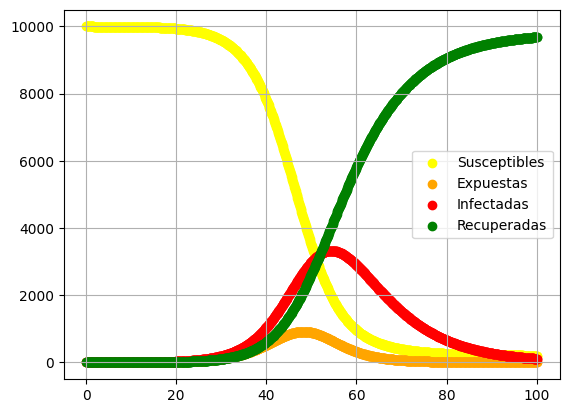

In [7]:
tiempos, susceptibles, expuestas, infectadas, recuperadas = euler(9999, 0, 1, 0, 0.4, 0.1, 0.5, 10000, 0, 100, 0.1)

plt.scatter(tiempos, susceptibles, label='Susceptibles', color='yellow')
plt.scatter(tiempos, expuestas, label='Expuestas', color='orange')
plt.scatter(tiempos, infectadas, label='Infectadas', color='red')
plt.scatter(tiempos, recuperadas, label='Recuperadas', color='green')

plt.legend()
plt.grid(True)
plt.show()